# Ejercicio 1

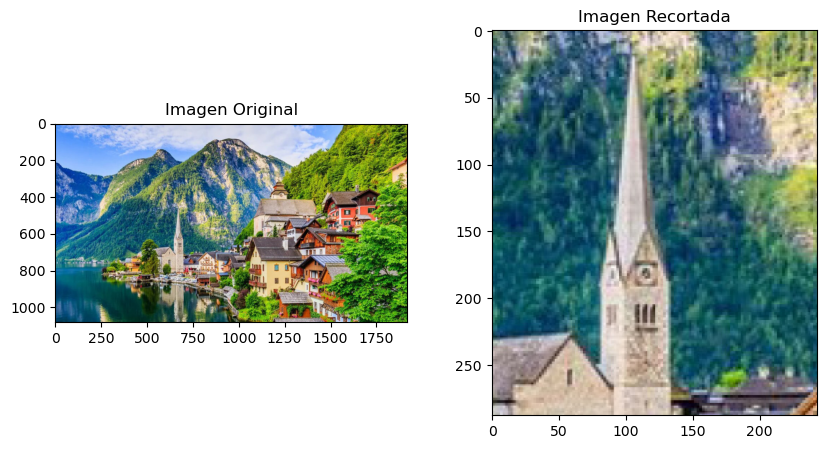

In [44]:
import cv2 
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('imagenP.jpeg')
img_recortada = img[445:733, 565:808] 

cv2.imwrite('imagenP_recortada.jpg', img_recortada)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.title('Imagen Original')
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

plt.subplot(1, 2, 2)
plt.title('Imagen Recortada')
plt.imshow(cv2.cvtColor(img_recortada, cv2.COLOR_BGR2RGB))
plt.show() 

# Ejercicio 2

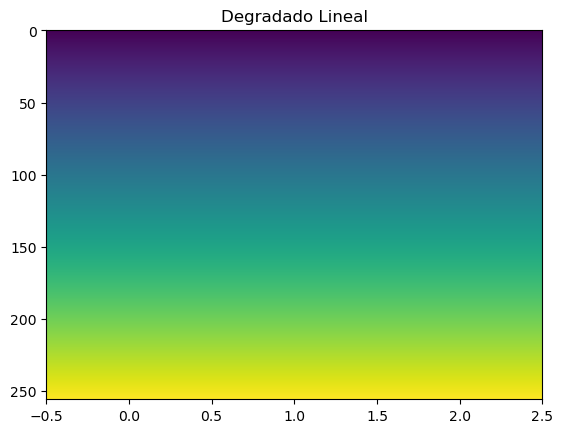

In [59]:
import numpy as np
import matplotlib.pyplot as plt

tamano = 256
imagen = np.zeros((tamano, 3), dtype=np.uint8)

for fila in range(tamano):
    imagen[fila, :] = fila

plt.imshow(imagen, aspect='auto')

plt.title("Degradado Lineal")
plt.show()


# Ejercicio 3

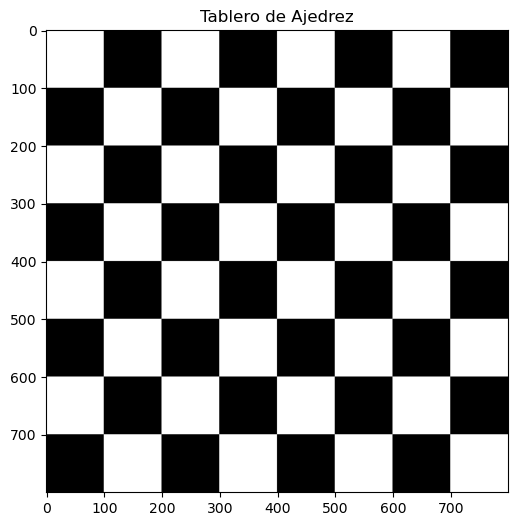

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

casilla = 100
filas = 8
columnas = 8
tamano_x = columnas * casilla
tamano_y = filas * casilla

imagen = np.ones((tamano_y, tamano_x), dtype=np.uint8) * 255

for fila in range(filas):
    for col in range(columnas):
        # Calculamos donde empieza y termina cada casilla en pixeles
        y_ini = fila * casilla
        y_fin = y_ini + casilla
        x_ini = col * casilla
        x_fin = x_ini + casilla
        
        if (fila + col) % 2 != 0:
            imagen[y_ini:y_fin, x_ini:x_fin] = 0

plt.figure(figsize=(6,6))
plt.imshow(imagen, cmap='gray')
plt.title("Tablero de Ajedrez")
plt.show()


# Ejercicio 4

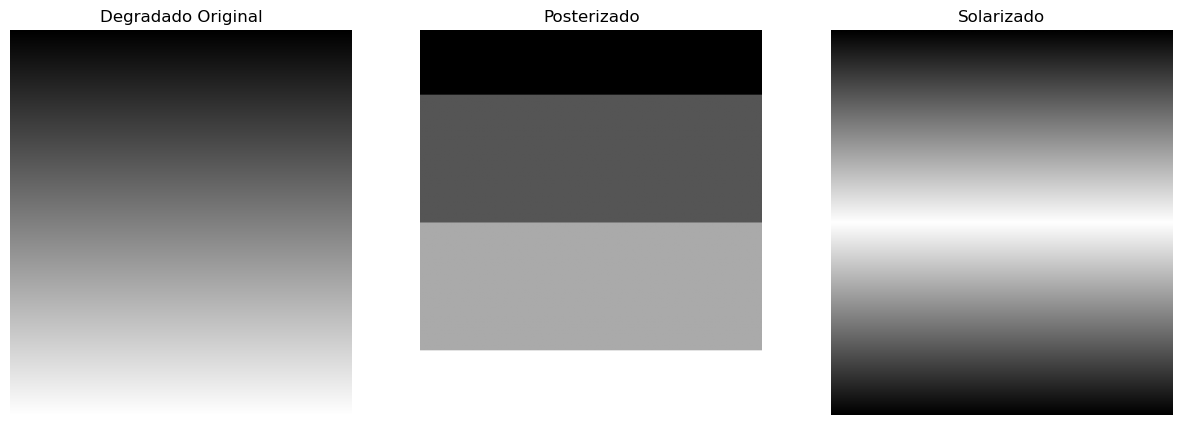

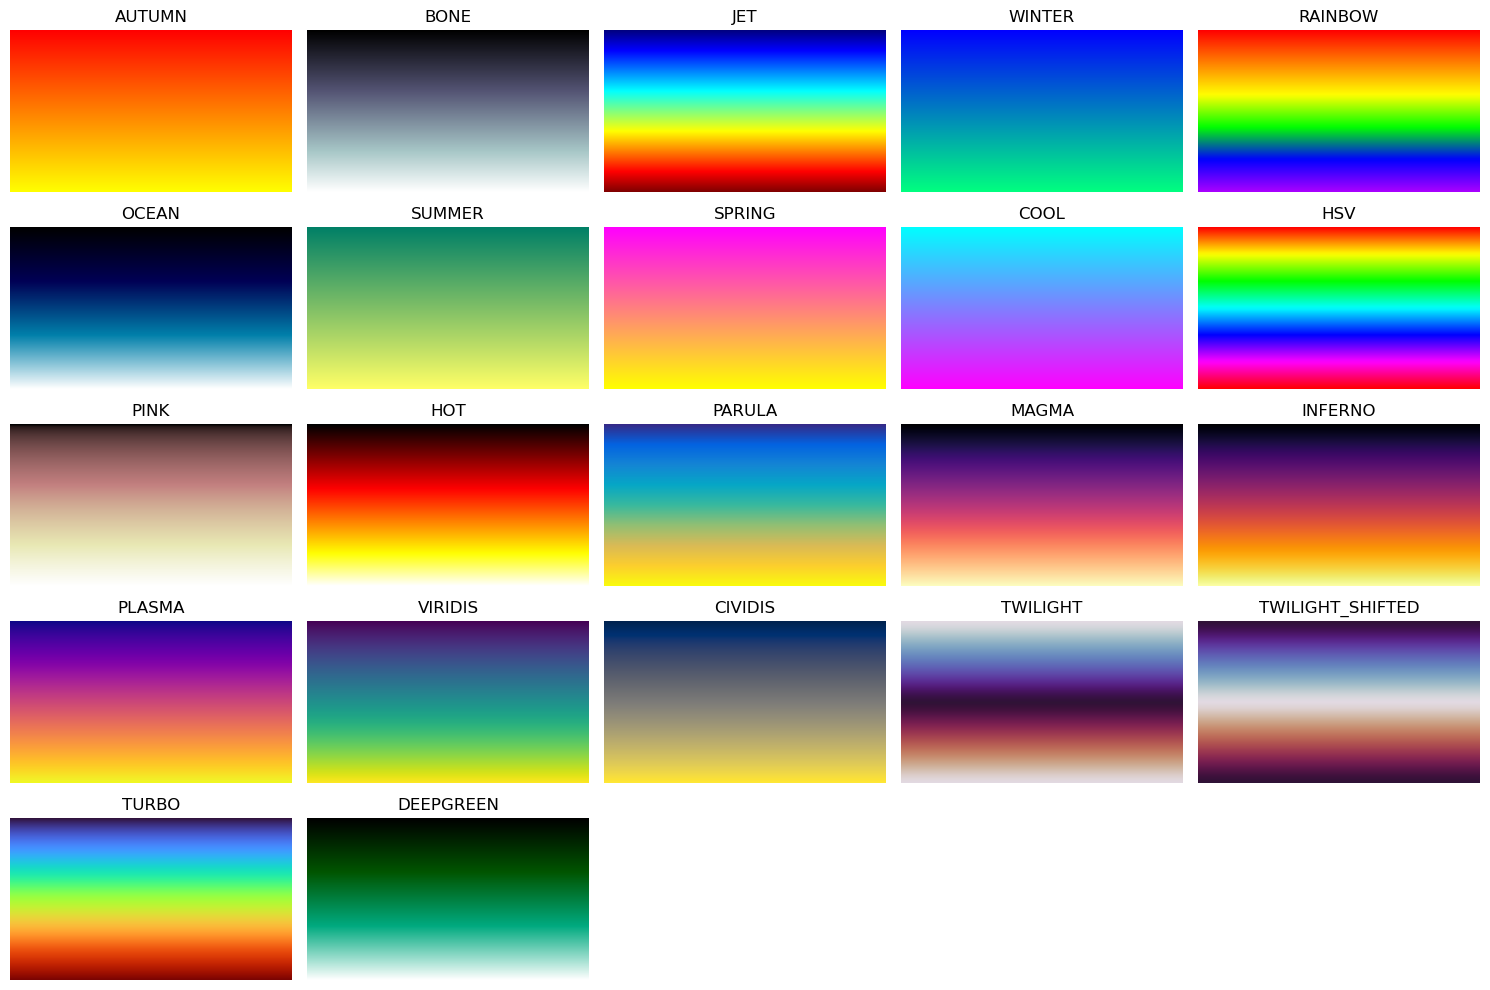

In [62]:
import cv2 
import numpy as np
import matplotlib.pyplot as plt

tamano = 256
ancho = 300
img_gray = np.zeros((tamano, ancho), dtype=np.uint8)

for fila in range(tamano):
    img_gray[fila, :] = fila

def posterizar(imagen, niveles):
    factor_escala = 255 / niveles
    img_pos = np.round(imagen / factor_escala) * factor_escala
    return img_pos.astype(np.uint8)

def solarizar(imagen, umbral):
    imagen_sol = np.where(imagen < umbral, imagen, 255 - imagen)
    return imagen_sol

def falso_color(img_grises, colormap):
    escal_img = cv2.normalize(img_grises, None, 0, 255, cv2.NORM_MINMAX)
    falso_img = cv2.applyColorMap(escal_img, colormap)
    return falso_img

nvl = 3
img_posterizada = posterizar(img_gray, nvl)
cv2.imwrite("posterizado.jpg", img_posterizada)

umbral = 127
img_solarizada = solarizar(img_gray, umbral)
cv2.imwrite("solarizado.jpg", img_solarizada)

colormaps = [
    ("AUTUMN", cv2.COLORMAP_AUTUMN), ("BONE", cv2.COLORMAP_BONE),
    ("JET", cv2.COLORMAP_JET), ("WINTER", cv2.COLORMAP_WINTER),
    ("RAINBOW", cv2.COLORMAP_RAINBOW), ("OCEAN", cv2.COLORMAP_OCEAN),
    ("SUMMER", cv2.COLORMAP_SUMMER), ("SPRING", cv2.COLORMAP_SPRING),
    ("COOL", cv2.COLORMAP_COOL), ("HSV", cv2.COLORMAP_HSV),
    ("PINK", cv2.COLORMAP_PINK), ("HOT", cv2.COLORMAP_HOT),
    ("PARULA", cv2.COLORMAP_PARULA), ("MAGMA", cv2.COLORMAP_MAGMA),
    ("INFERNO", cv2.COLORMAP_INFERNO), ("PLASMA", cv2.COLORMAP_PLASMA),
    ("VIRIDIS", cv2.COLORMAP_VIRIDIS), ("CIVIDIS", cv2.COLORMAP_CIVIDIS),
    ("TWILIGHT", cv2.COLORMAP_TWILIGHT), ("TWILIGHT_SHIFTED", cv2.COLORMAP_TWILIGHT_SHIFTED),
    ("TURBO", cv2.COLORMAP_TURBO), ("DEEPGREEN", cv2.COLORMAP_DEEPGREEN)
]

for nombre, cmap in colormaps:
    img_color = falso_color(img_gray, cmap)
    cv2.imwrite(f"Paleta_{nombre}.jpg", img_color)


plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.title("Degradado Original")
plt.imshow(img_gray, cmap='gray', aspect='auto')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("Posterizado")
plt.imshow(img_posterizada, cmap='gray', aspect='auto')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("Solarizado")
plt.imshow(img_solarizada, cmap='gray', aspect='auto')
plt.axis('off')

plt.figure(figsize=(15, 10))

filas = 5
columnas = 5 

for i, (nombre, cmap) in enumerate(colormaps):
    img_color = falso_color(img_gray, cmap)
    
    plt.subplot(filas, columnas, i + 1)
    plt.title(nombre)
    plt.imshow(cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB), aspect='auto')
    plt.axis('off')

plt.tight_layout()
plt.show()



# Ejercicio 5

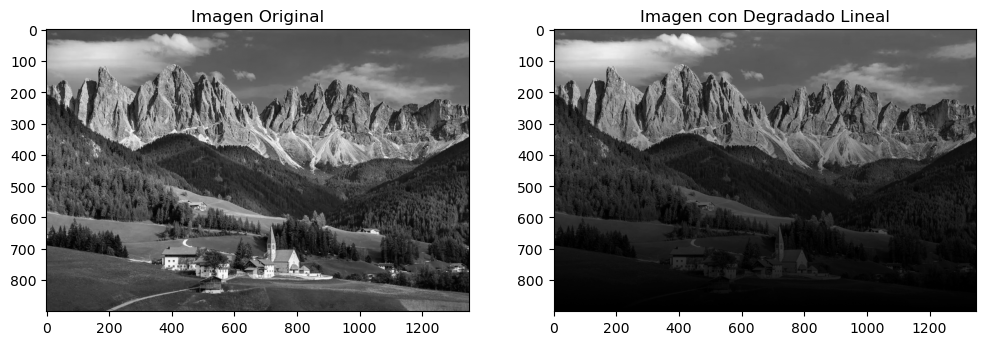

In [69]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img_original = cv2.imread('imagen1.jpeg', 0)
alto, ancho = img_original.shape

mascara = np.zeros((alto, ancho), dtype=np.float32)

for fila in range(alto):
    valor = 1.0 - (fila / (alto - 1))
    
    mascara[fila, :] = valor

img_resultado = img_original * mascara
img_resultado = img_resultado.astype(np.uint8)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title("Imagen Original")
plt.imshow(img_original, cmap='gray')

plt.subplot(1, 2, 2)
plt.title("Imagen con Degradado Lineal")
plt.imshow(img_resultado, cmap='gray')

plt.show()


# Ejercicio 6

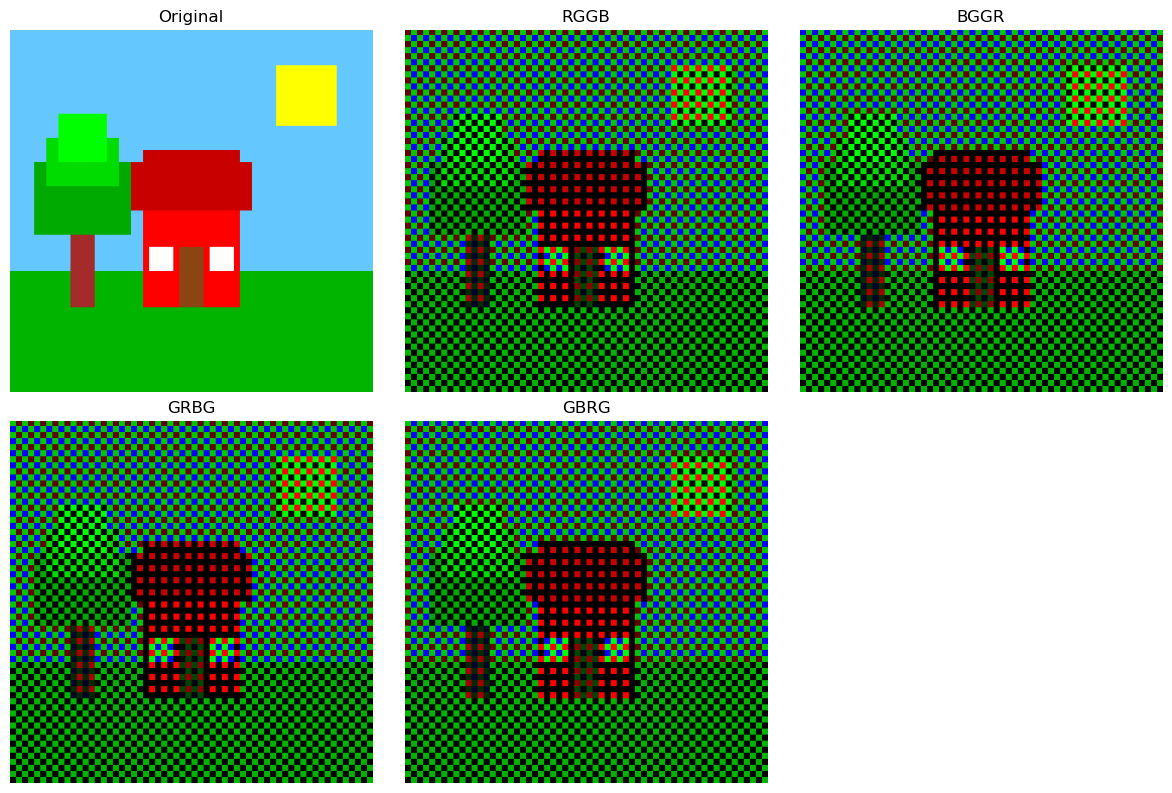

In [19]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

img = np.zeros((300, 300, 3), dtype=np.uint8)

img[:, :] = [255, 200, 100]

img[200:300, :] = [0, 180, 0]

img[30:80, 220:270] = [0, 255, 255]

img[150:230, 110:190] = [0, 0, 255]

img[110:150, 100:200] = [0, 0, 200]
img[100:110, 110:190] = [0, 0, 200]

img[180:230, 140:160] = [19, 69, 139]

img[180:200, 115:135] = [255, 255, 255]
img[180:200, 165:185] = [255, 255, 255]

img[170:230, 50:70] = [42, 42, 165]

img[110:170, 20:100] = [0, 170, 0]
img[90:130, 30:90] = [0, 220, 0]
img[70:110, 40:80] = [0, 255, 0]

cv2.imwrite("imagen_Creada.jpg", img)

# Reducirmos la imagen
img_small = cv2.resize(img, (60, 60), interpolation=cv2.INTER_NEAREST)

def aplicar_bayer(img, patron):
    h, w, _ = img.shape
    bayer = np.zeros_like(img)

    for i in range(h):
        for j in range(w):

            if patron == "RGGB":
                if i % 2 == 0 and j % 2 == 0:
                    bayer[i,j,2] = img[i,j,2]
                elif i % 2 == 0 and j % 2 == 1:
                    bayer[i,j,1] = img[i,j,1]
                elif i % 2 == 1 and j % 2 == 0:
                    bayer[i,j,1] = img[i,j,1]
                else:
                    bayer[i,j,0] = img[i,j,0]

            elif patron == "BGGR":
                if i % 2 == 0 and j % 2 == 0:
                    bayer[i,j,0] = img[i,j,0]
                elif i % 2 == 0 and j % 2 == 1:
                    bayer[i,j,1] = img[i,j,1]
                elif i % 2 == 1 and j % 2 == 0:
                    bayer[i,j,1] = img[i,j,1]
                else:
                    bayer[i,j,2] = img[i,j,2]

            elif patron == "GRBG":
                if i % 2 == 0 and j % 2 == 0:
                    bayer[i,j,1] = img[i,j,1]
                elif i % 2 == 0 and j % 2 == 1:
                    bayer[i,j,2] = img[i,j,2]
                elif i % 2 == 1 and j % 2 == 0:
                    bayer[i,j,0] = img[i,j,0]
                else:
                    bayer[i,j,1] = img[i,j,1]

            elif patron == "GBRG":
                if i % 2 == 0 and j % 2 == 0:
                    bayer[i,j,1] = img[i,j,1]
                elif i % 2 == 0 and j % 2 == 1:
                    bayer[i,j,0] = img[i,j,0]
                elif i % 2 == 1 and j % 2 == 0:
                    bayer[i,j,2] = img[i,j,2]
                else:
                    bayer[i,j,1] = img[i,j,1]

    return bayer

patrones = ["RGGB", "BGGR", "GRBG", "GBRG"]
resultados = []

for p in patrones:
    img_bayer = aplicar_bayer(img_small, p)
    img_bayer_zoom = cv2.resize(img_bayer, (300, 300), interpolation=cv2.INTER_NEAREST)
    resultados.append((p, img_bayer_zoom))
    cv2.imwrite(f"Bayer_{p}.jpg", img_bayer_zoom)

plt.figure(figsize=(12, 8))

plt.subplot(2, 3, 1)
plt.title("Original")
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')

for i, (nombre, imagen) in enumerate(resultados):
    plt.subplot(2, 3, i+2)
    plt.title(nombre)
    plt.imshow(cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB))
    plt.axis('off')

plt.tight_layout()
plt.show()
